# hydromend on synthetic data — recovering a known Volterra operator

`hydromend` does not care where the two series come from: give it **any** model
output and **any** target, and it learns the lag operator between them. This
notebook makes that concrete on *totally synthetic* data, in the spirit of the
shallow-water experiments in the paper — but with **no solver**: we build a
system whose true lag kernel we *choose*, then check that hydromend recovers it.

The set-up mirrors a reduced-physics model vs. reality:

* **model** (the predictor) — a tide (M2 + S2) plus a few storm surges. Think of
  it as an "arbitrary model" output: a barotropic reanalysis, an emulator, a
  reduced simulation, anything.
* **observations** (the target) — the same signal passed through a known
  **second-order Volterra operator**: a smooth linear lag response *plus*
  quadratic (bilinear) terms that inject overtides and tide–surge interaction —
  the shallow-water non-linearity a linear correction cannot represent.

We then fit a **linear** and a **bilinear** operator (default VB-ARD), evaluate
out-of-sample, recover the kernels, and look at the spectrum.

In [1]:
import os
for v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(v, "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import hydromend as hm

rng = np.random.default_rng(7)
print("hydromend", hm.__version__)

hydromend 0.1.0


## 1. An arbitrary "model" series

Hourly for 220 days: two tidal constituents (a 14.8-day spring–neap beat) plus a
handful of storm surges. Nothing here is tide-gauge specific — it is just a
`DataFrame` with a numeric predictor column.

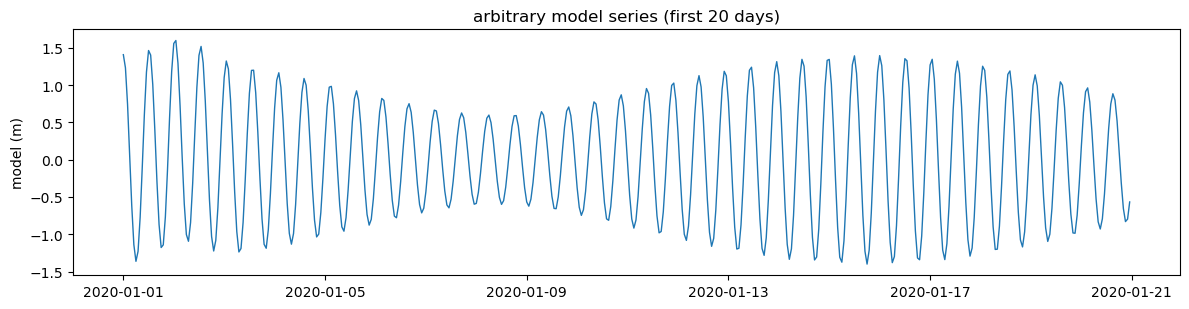

In [2]:
hours = 220 * 24
t = np.arange(hours)                               # hours
idx = pd.date_range("2020-01-01", periods=hours, freq="1h")

# tide: M2 (12.42 h) + S2 (12.00 h)  -> spring-neap beat
tide = 1.0 * np.cos(2*np.pi*t/12.42) + 0.4 * np.cos(2*np.pi*t/12.00)

# a few storms: Gaussian bumps at random onsets
surge = np.zeros(hours)
for onset in rng.uniform(0, hours, 8):
    width = rng.uniform(8, 20)
    amp = rng.uniform(0.2, 0.6)
    surge += amp * np.exp(-0.5 * ((t - onset) / width) ** 2)

model = pd.Series(tide + surge, index=idx, name="model")
df = model.to_frame()

fig, ax = plt.subplots(figsize=(12, 3.2))
ax.plot(df.index[:24*20], model.values[:24*20], lw=1.0)
ax.set_ylabel("model (m)"); ax.set_title("arbitrary model series (first 20 days)")
fig.tight_layout()

## 2. A *known* Volterra operator defines the target

We define the ground truth **in hydromend's own feature space**, so the true
operator is expressible. The recipe is a 12 h memory with the full bilinear
feature set (`include_squares=True` keeps the τ₁=τ₂ diagonal — the overtide terms).

True weights:

* linear: a smooth decaying response over the first few lags,
* bilinear: a lag-0 **self-product** (→ overtides), a lag-2 self-product, and a
  lag-0 × lag-3 **cross term** (→ tide–surge interaction).

Everything else is exactly zero.

In [3]:
RECIPE = dict(predictor_columns=("model",), lags_hours=list(range(1, 13)),
              feature_set="bilinear", include_current=True, include_squares=True)

Xtrue = hm.build_feature_set(df, **RECIPE)
w_true = pd.Series(0.0, index=Xtrue.columns)

# linear lag response (smooth, decaying)
w_true["model"]       = 0.90     # lag 0
w_true["model_lag1"]  = 0.15
w_true["model_lag2"]  = 0.05
# bilinear (Volterra) terms
w_true["model_x_model"]            = 0.08   # lag0 x lag0  -> overtide (M4, M6, ...)
w_true["model_lag2_x_model_lag2"]  = 0.04   # lag2 x lag2  -> overtide
w_true["model_x_model_lag3"]       = 0.05   # lag0 x lag3  -> interaction

noise = 0.01 * rng.standard_normal(len(df))
df["observations"] = Xtrue.values @ w_true.values + noise
df = df.dropna()
print(f"{len(df):,} hourly samples | {int((w_true != 0).sum())} non-zero true weights "
      f"of {len(w_true)} features")

5,268 hourly samples | 6 non-zero true weights of 104 features


## 3. Fit linear and bilinear operators (train, then test)

Hold out the last third. Fit both a linear and a bilinear operator with the
default variational-Bayes ARD estimator. The linear operator can only re-weight
lags; only the bilinear operator can reproduce the injected quadratic terms.

In [4]:
def fit_operator(df, feature_set):
    recipe = {**RECIPE, "feature_set": feature_set}
    X = hm.build_feature_set(df, **recipe)
    d = pd.concat([X, df["observations"]], axis=1).dropna()
    split = int(len(d) * 0.67)
    tr, te = d.iloc[:split], d.iloc[split:]
    reg = hm.make_regressor().fit(tr[X.columns], tr["observations"])      # default: vb_ard
    pred = pd.Series(reg.predict(te[X.columns]), index=te.index)
    return reg, X.columns, te, pred

reg_lin, cols_lin, te, pred_lin = fit_operator(df, "linear")
reg_bil, cols_bil, te_b, pred_bil = fit_operator(df, "bilinear")

y_te = te_b["observations"]
base = df["model"].reindex(y_te.index)
base = base - (base.mean() - y_te.mean())            # datum-match the raw baseline
mae = lambda a, b: float((a - b).abs().mean())
print(f"held-out MAE   baseline {mae(y_te, base):.4f}   "
      f"linear {mae(y_te, pred_lin.reindex(y_te.index)):.4f}   "
      f"bilinear {mae(y_te, pred_bil):.4f}  m")

held-out MAE   baseline 0.0952   linear 0.0513   bilinear 0.0081  m


## 4. Time series and out-of-sample error distribution

The linear operator tracks the tide but leaves a structured residual; the
bilinear operator removes it down to the noise floor.

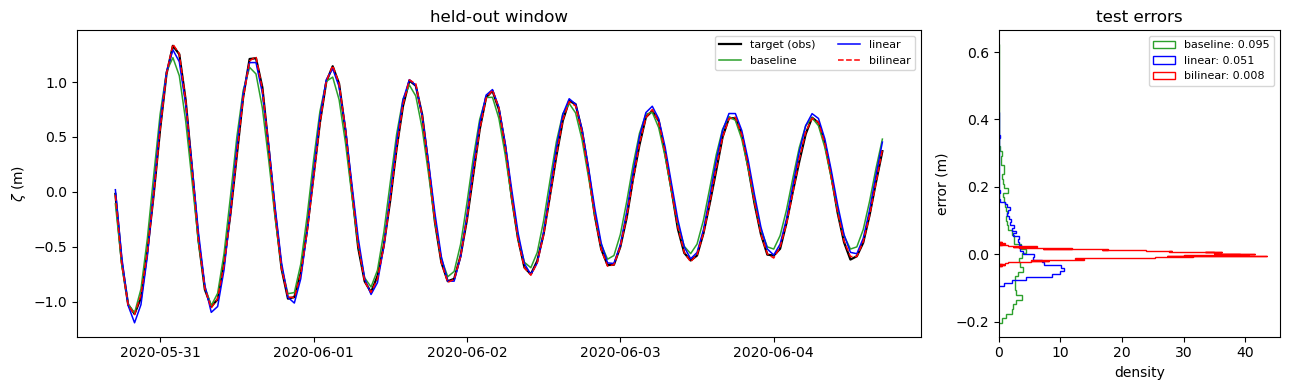

In [5]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [3, 1]})
win = slice(y_te.index[24*3], y_te.index[24*8])
a0.plot(y_te[win].index, y_te[win], "k", lw=1.6, label="target (obs)")
a0.plot(base[win].index, base[win], color="#2ca02c", lw=1.1, label="baseline")
a0.plot(pred_lin[win].index, pred_lin[win], "b", lw=1.1, label="linear")
a0.plot(pred_bil[win].index, pred_bil[win], "r--", lw=1.1, label="bilinear")
a0.set_ylabel("$\\zeta$ (m)"); a0.set_title("held-out window"); a0.legend(ncol=2, fontsize=8)

for e, c, lab in [(y_te - base, "#2ca02c", "baseline"),
                  (y_te - pred_lin.reindex(y_te.index), "b", "linear"),
                  (y_te - pred_bil, "r", "bilinear")]:
    a1.hist(e, bins=60, orientation="horizontal", histtype="step", color=c,
            density=True, label=f"{lab}: {e.abs().mean():.3f}")
a1.set_xlabel("density"); a1.set_ylabel("error (m)"); a1.set_title("test errors")
a1.legend(fontsize=8)
fig.tight_layout()

## 5. The learned operator is interpretable

The point of a Volterra operator is that the weights *mean* something. The
**linear kernel** is well-identified and matches the imposed response. The
**bilinear kernel** concentrates on the same diagonal (overtide) and near-diagonal
(interaction) structure as the imposed mechanism — though individual off-diagonal
cells are not uniquely pinned down: with narrowband tidal forcing, neighbouring
lag-products are collinear, so ARD spreads weight among them (a smoothing GP prior,
`make_regressor("gp_volterra")`, or broadband forcing sharpens this). What *is*
identified is the operator as a **function**: the learned and imposed operators
make near-identical predictions.

learned vs imposed operator on test: MAE 0.0005 m, corr 1.00000


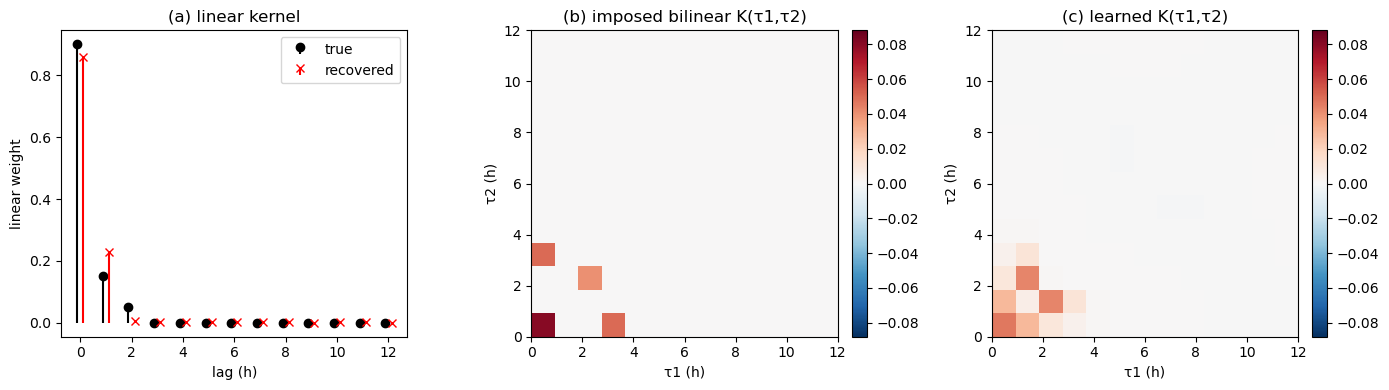

In [6]:
LAGS = [0] + RECIPE["lags_hours"]                         # 0..12 h
def lag_of(part):
    return 0 if part == "model" else int(part.split("_lag")[1])

def linear_vec(coef, cols):
    v = pd.Series(0.0, index=LAGS)
    for c, w in zip(cols, coef):
        if "_x_" not in c:
            v[lag_of(c)] = w
    return v

def kernel_mat(coef, cols):
    K = pd.DataFrame(0.0, index=LAGS, columns=LAGS)
    for c, w in zip(cols, coef):
        if "_x_" in c:
            a, b = c.split("_x_"); i, j = lag_of(a), lag_of(b)
            K.loc[i, j] = w; K.loc[j, i] = w
    return K

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
# linear kernel: true vs recovered
lt = linear_vec(w_true.values, w_true.index)
lr = linear_vec(reg_bil.coef_, cols_bil)
ax[0].stem(np.array(LAGS) - 0.12, lt.values, linefmt="k-", markerfmt="ko", basefmt=" ", label="true")
ax[0].stem(np.array(LAGS) + 0.12, lr.values, linefmt="r-", markerfmt="rx", basefmt=" ", label="recovered")
ax[0].set_xlabel("lag (h)"); ax[0].set_ylabel("linear weight"); ax[0].set_title("(a) linear kernel"); ax[0].legend()

Kt = kernel_mat(w_true.values, w_true.index)
Kr = kernel_mat(reg_bil.coef_, cols_bil)
vmax = float(np.abs(Kt.values).max()) * 1.1
for a, K, ttl in [(ax[1], Kt, "(b) imposed bilinear K(τ1,τ2)"), (ax[2], Kr, "(c) learned K(τ1,τ2)")]:
    im = a.imshow(K.values, origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                  extent=[0, 12, 0, 12])
    a.set_xlabel("τ1 (h)"); a.set_ylabel("τ2 (h)"); a.set_title(ttl)
    fig.colorbar(im, ax=a, fraction=0.046, pad=0.04)
fig.tight_layout()

# Functional equivalence: learned vs imposed operator make the same prediction
w_true_vec = w_true.reindex(cols_bil).values
imposed = pd.Series(te_b[list(cols_bil)].values @ w_true_vec, index=te_b.index)
print(f"learned vs imposed operator on test: "
      f"MAE {(pred_bil - imposed).abs().mean():.4f} m, "
      f"corr {np.corrcoef(pred_bil, imposed)[0, 1]:.5f}")

## 6. Overtides in the spectrum

The quadratic terms create energy at the **M4 overtide** (twice the M2 frequency)
and at tide–tide sum/difference frequencies — all essentially absent from the
model. A linear filter can never manufacture new frequencies; only the bilinear
operator reproduces them. (A quadratic operator makes 2f components, not 3f, so
M6 is *not* generated — it needs a third-order term.)

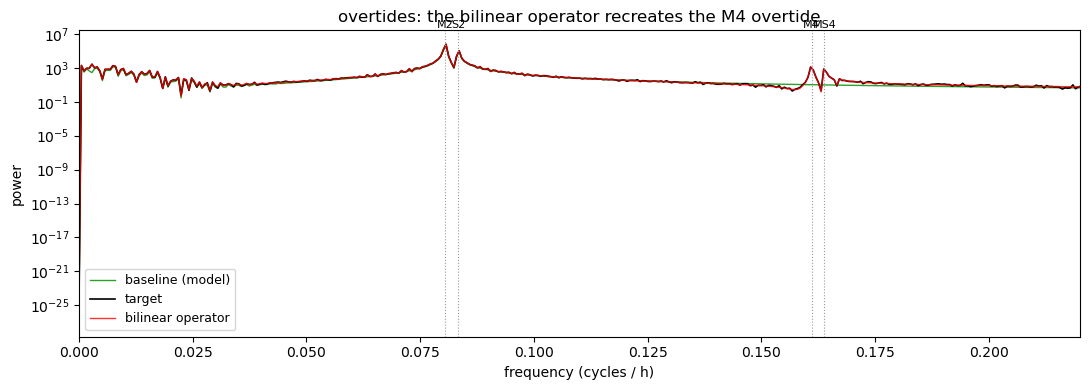

In [7]:
def psd(x):
    x = np.asarray(x) - np.mean(x)
    f = np.fft.rfftfreq(len(x), d=1.0)              # cycles per hour
    return f, (np.abs(np.fft.rfft(x)) ** 2)

f, P_t = psd(y_te.values)
_, P_b = psd(base.values)
_, P_bil = psd(pred_bil.values)

fig, ax = plt.subplots(figsize=(11, 4))
ax.semilogy(f, P_b, color="#2ca02c", lw=1.0, label="baseline (model)")
ax.semilogy(f, P_t, "k", lw=1.2, label="target")
ax.semilogy(f, P_bil, "r", lw=1.0, alpha=0.8, label="bilinear operator")
for name, fr in [("M2", 1/12.42), ("S2", 1/12.00), ("MS4", 1/12.42 + 1/12.00), ("M4", 2/12.42)]:
    ax.axvline(fr, color="0.6", ls=":", lw=0.8)
    ax.text(fr, ax.get_ylim()[1], name, ha="center", va="bottom", fontsize=8)
ax.set_xlim(0, 0.22); ax.set_xlabel("frequency (cycles / h)"); ax.set_ylabel("power")
ax.set_title("overtides: the bilinear operator recreates the M4 overtide"); ax.legend(fontsize=9)
fig.tight_layout()

## 7. Arbitrary models — nothing is tide-gauge specific

The predictor column can be named anything, and you can feed **several**
predictors: `build_feature_set` then also forms their cross-interactions, so a
bilinear operator captures, say, tide × wind coupling. Here we add an
independent forcing `wind` and let the operator use both.

In [8]:
df2 = df.copy()
wind = np.zeros(len(df2))
for onset in rng.uniform(0, len(df2), 10):
    wind += rng.uniform(0.2, 0.8) * np.exp(-0.5 * ((np.arange(len(df2)) - onset) / rng.uniform(6, 15)) ** 2)
df2["wind"] = wind
# a target that couples model and wind (tide-surge-like interaction)
Xm = hm.build_feature_set(df2, predictor_columns=("model", "wind"), lags_hours=[1, 2, 3],
                          feature_set="bilinear", include_current=True, include_squares=True)
df2["observations"] = (df2["observations"]
                       + 0.10 * Xm["model_x_wind"].fillna(0.0)          # cross-predictor term
                       + 0.05 * Xm["wind_lag1_x_wind_lag1"].fillna(0.0))

recipe2 = dict(predictor_columns=("model", "wind"), lags_hours=[1, 2, 3],
               feature_set="bilinear", include_current=True, include_squares=True)
X2 = hm.build_feature_set(df2, **recipe2)
d2 = pd.concat([X2, df2["observations"]], axis=1).dropna()
sp = int(len(d2) * 0.67)
reg2 = hm.make_regressor().fit(d2.iloc[:sp][X2.columns], d2.iloc[:sp]["observations"])
p2 = pd.Series(reg2.predict(d2.iloc[sp:][X2.columns]), index=d2.iloc[sp:].index)
yv = d2.iloc[sp:]["observations"]
print(f"two predictors (model + wind): {X2.shape[1]} features incl. cross terms like 'model_x_wind'")
print(f"held-out MAE with both predictors: {float((yv - p2).abs().mean()):.4f} m")

op = hm.Operator.from_regressor(reg2, feature_names=list(X2.columns), **recipe2,
                                metadata={"site": "synthetic-2predictor"})
print("saved operator applies to any (model, wind) frame ->", repr(op))

two predictors (model + wind): 44 features incl. cross terms like 'model_x_wind'
held-out MAE with both predictors: 0.0081 m
saved operator applies to any (model, wind) frame -> <Operator synthetic-2predictor bilinear n_lags=3 n_feat=44>


## Takeaways

* `hydromend` operates on **any** `DataFrame` of a numeric predictor and a target
  — GTSM/GESLA is just one instance. Rename the column, or pass several via
  `predictor_columns`.
* A **linear** operator re-weights lags; a **bilinear** (Volterra) operator adds
  the quadratic terms that create overtides and cross-predictor interaction.
* The learned weights are **interpretable** and, on a controlled system, recover
  the true kernel — and every fitted operator serialises to an `Operator` /
  `OperatorLibrary` for reuse (see `quickstart.ipynb`).